## Universal Language Model Fine-tuning (ULMFit) in NLP


Understanding human language is one of the toughest challenges for computers. ULMFit (Universal Language Model Fine-tuning) is a technique used that helps machines learn language by first studying a large amount of text and then quickly adapting to specific language tasks. This makes building language-based applications faster and more accurate even if a small amount of data is available. Its core concepts are:

* The main idea behind ULMFit is to first train a language model on a very large amount of general text data this step is called pre-training and it helps the model to learn the overall structure of the language like grammar, common phrases and how words relate to each other.

* Think of it like teaching the model the basics of the language similar to how a person learns by reading or listening to many conversations. After this ULMFit fine-tunes the model on a smaller, specific dataset related to the task we want to solve such as classifying texts, detecting sentiment or answering questions.

* Before ULMFit most NLP models were built from scratch for each task which took a lot of time and computing power. It changed this by showing that a model already trained on general language data can be quickly adapted to new tasks with less data and training time. This improves performance when task-specific data is limited.

### Core Concepts

It uses some important math concepts that help it learn language well and adapt to different tasks:

* **Neural Networks (LSTM):** At its core ULMFit uses a type of neural network known as a Long Short-Term Memory (LSTM). LSTMs are good at understanding sequences like sentences because they can remember important information from earlier words to understand the meaning of the whole sentence. It’s like having a memory that keeps track of previous words to understand what comes next.
* **Embeddings:** Instead of just using words as plain text it turns words into numbers called vectors in a high-dimensional space. This is called word embeddings. Words that have similar meanings are placed closer together in this space. For example “king” and “queen” will be closer to each other than “king” and “car.”
* **Gradient Descent and Learning Rate:** It uses gradient descent to minimize errors during training. The learning rate controls the size of each step helps in changes over time. Initially the learning rate increases quickly to help the model adapt fast then decreases gradually to fine-tune the model's performance. This approach is called Slanted Triangular Learning Rates.
* **Transfer Learning:** The main idea behind ULMFit is transfer learning where the model learns from a large general language corpus like books or Wikipedia and uses that knowledge to quickly adapt to specific tasks like sentiment analysis or text classification. This reduces the amount of task-specific data required and helps in making it more efficient than training models from scratch.

These math concepts help ULMFit to learn from language data and adjust to new tasks quickly and make good predictions.

### Working

ULMFit works through a multi-step process which is divided into pre-training on general data, fine-tuning on task-specific data and additional techniques to optimize its learning:

* **Pre-trained Language Model:** First a neural network is trained on a large amount of general text like Wikipedia articles. This helps the model to learn how the language works like its grammar, common phrases and how words connect. Think of it like the model reading a lot of books to learn the language basics.
* **Fine-tuning on Target Task:** After that the model is adjusted using data for a specific task like finding out if a review is positive or negative or sorting news articles. This step helps the model get better at the particular task by learning from examples related to it.
* **Discriminative Fine-tuning and Gradual Unfreezing:** To keep what the model already knows and avoid forgetting, we train different parts of the model at different speeds. We also slowly “unfreeze” the layers one by one starting from the last layer. It’s like carefully tuning different parts of a machine without breaking it.
* **Classifier Fine-tuning:** Finally a new layer called a classifier is added on top. This layer makes the final decision like labeling a sentence as positive or negative. It’s like adding the finishing touch to the machine to do the specific task.


## Implementation of ULMFit for Text Classifications


Lets see an example which shows how to use ULMFit to build a text classification model using the FastAI library. Here we use the code which downloads a dataset, prepares it, trains the model and checks how well it performs.

First we need to ensure that we have installed FastAI library, if not then Install it using the below command:

**!pip install fastai**

### Step 1: Importing Libraries

In [1]:
from fastai.text.all import *
import pandas as pd
import numpy as np

### Step 2: Downloading Dataset

* path = untar_data(URLs.AG_NEWS): Downloads the AG News dataset from FastAI's repository and extracts it.
* path stores the location of the extracted files

In [2]:
path = untar_data(URLs.AG_NEWS)

<div><progress max="11784419" value="11788288"></progress> 100.03% [11788288/11784419 00:09&lt;00:00]</div>

### Step 3: Preparing Dataset

* Load the dataset into a Pandas DataFrame.
* Assign column names for better readability.
* Combine the title and description columns into a single text column.
* Save the modified data to a new CSV file for training.

In [3]:
df = pd.read_csv(path/'train.csv', header=None)


In [5]:
df.head(3)

,0,1,2
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again."
1,3,Carlyle Looks Toward Commercial Aerospace (Reuters),"Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market."
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums.


In [8]:
df = pd.read_csv(path/'train.csv', header=None)
df.columns = ['label', 'title', 'description']
df['text'] = df['title'] + ' ' + df['description']
df.to_csv(path/'train_modified.csv', index=False)

In [9]:
df.head(2)

,label,title,description,text
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.","Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again."
1,3,Carlyle Looks Toward Commercial Aerospace (Reuters),"Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.","Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market."


### Step 4: Creating DataLoaders

In [10]:
dls = TextDataLoaders.from_csv(path, 'train_modified.csv', text_col='text', label_col='label', valid_pct=0.2, is_lm=False)

Due to IPython and Windows limitation, python multiprocessing isn't available now.
So `n_workers` has to be changed to 0 to avoid getting stuck


### Step 5: Creating and Training Classifier

* learn = text_classifier_learner(...): Initializes a text classifier learner using the AWD_LSTM model and the data from dls.
*  learn.fit_one_cycle(1, 1e-2): Trains the model for one epoch with a learning rate of 0.01 (1e-2).

In [ ]:
learn = text_classifier_learner(dls, AWD_LSTM, drop_mult=0.5, metrics=accuracy)
learn.fine_tune(4, 1e-2)

### Step 6: Evaluating the Model

In [ ]:
accuracy = learn.validate()[1]
print(f'Validation Accuracy: {accuracy:.4f}')

### Real-world Applications

ULMFit is used in areas where understanding human language is important. Some key applications include:

* **Sentiment Analysis:** Businesses use ULMFit to analyze customer reviews and social media posts to understand opinions and feelings about products or services.
* **Document Classification:** Law firms, hospitals and other organizations use it to sort and organize large amounts of text documents quickly and accurately.
* **Language Translation:** ULMFit helps improve translation tools helps in making it easier for people speaking different languages to communicate.
* **Chatbots and Virtual Assistants:** It upgrade chatbots so they understand questions better and respond more naturally and accurately.

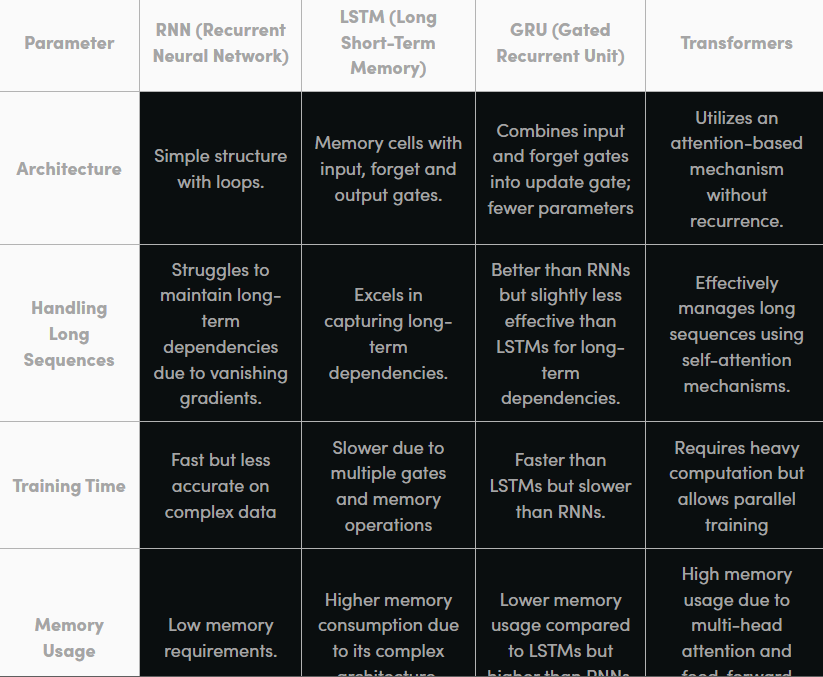
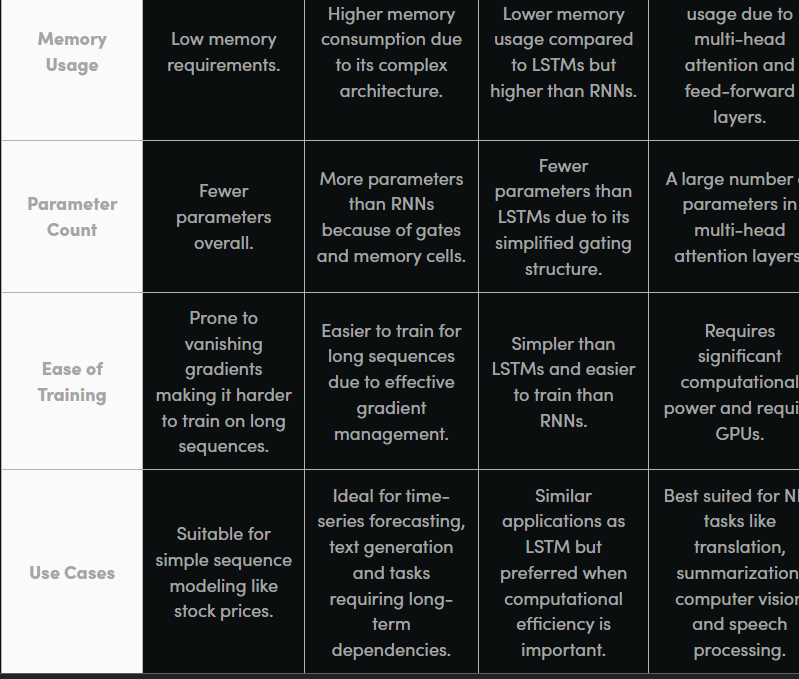
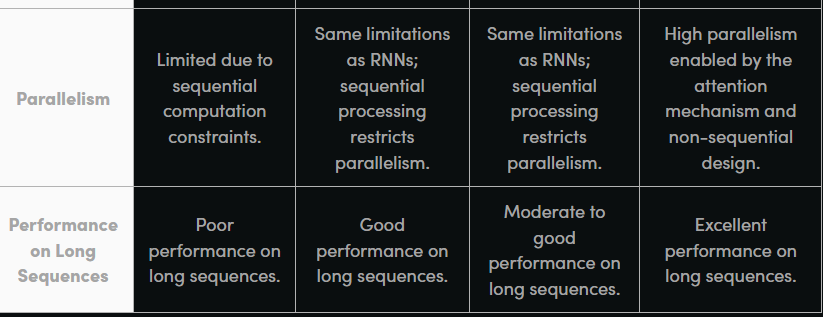